In [13]:
import re
import numpy as np
from urllib.parse import urlparse

def extract_features(url):

    features = []

    # Ensure lowercase
    url = url.lower()

    # Parse URL
    parsed = urlparse(url)
    domain = parsed.netloc

    # 1️⃣ URL Length
    features.append(len(url))

    # 2️⃣ Domain Length
    features.append(len(domain))

    # 3️⃣ Has @ symbol
    features.append(1 if "@" in url else 0)

    # 4️⃣ Number of dots
    features.append(url.count("."))

    # 5️⃣ Number of hyphens
    features.append(url.count("-"))

    # 6️⃣ Number of digits
    features.append(sum(c.isdigit() for c in url))

    # 7️⃣ Has IP address
    ip_pattern = r"\d+\.\d+\.\d+\.\d+"
    features.append(1 if re.search(ip_pattern, url) else 0)

    # 8️⃣ Uses HTTPS
    features.append(1 if parsed.scheme == "https" else 0)

    # 9️⃣ Suspicious words
    suspicious_words = ["login", "verify", "update", "bank", "secure", "free", "bonus"]
    features.append(1 if any(word in url for word in suspicious_words) else 0)

    # 🔟 Suspicious TLD
    suspicious_tlds = [".xyz", ".top", ".click", ".info"]
    features.append(1 if any(tld in url for tld in suspicious_tlds) else 0)

    return np.array(features)

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv("phishing_dataset_big.csv")

# Drop text column
X = df.drop(["URL", "Label"], axis=1)
y = df["Label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Accuracy
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 1.0


In [16]:
url = input("Enter URL: ")
features = extract_features(url)
prediction = model.predict([features])

if prediction[0] == 1:
    print("⚠️ Phishing Website")
else:
    print("✅ Safe Website")

Enter URL: unmildas06@gmail.com


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 10 features, but RandomForestClassifier is expecting 5 features as input.

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nFull Report:")
print(classification_report(y_test, y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0

Confusion Matrix:
[[199   0]
 [  0 201]]

Full Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       199
           1       1.00      1.00      1.00       201

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



               Feature  Importance
4  Has_Suspicious_Word    0.615011
0           URL_Length    0.331520
3               Has_IP    0.026927
2             Num_Dots    0.026542
1        Has_At_Symbol    0.000000


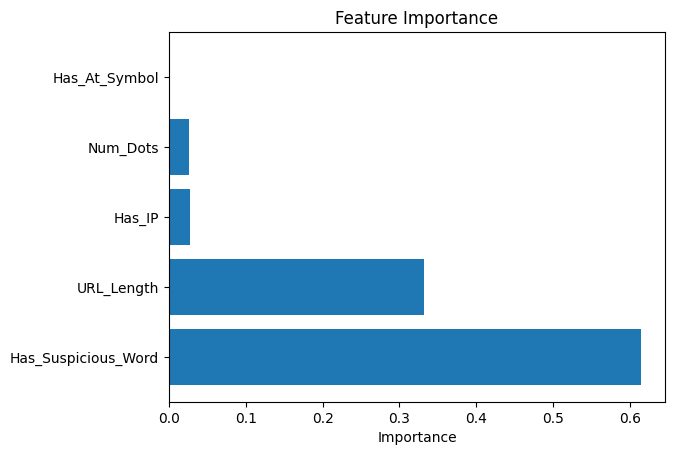

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

feature_names = X.columns
importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(importance_df)

plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance")

plt.show()

In [19]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

print("model.pkl file created successfully ✅")

model.pkl file created successfully ✅
